In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.utils import simple_preprocess
from spacy.lang.en.stop_words import STOP_WORDS
from transformers import AutoTokenizer, T5EncoderModel
import torch
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
import optuna
import os

output_path = "output"

In [116]:
dataset_full = pd.read_csv(f"{output_path}/Dataset.csv")
dataset_full['admit_date'] = pd.to_datetime(dataset_full['admit_date'])

TEXT_COLUMNS = ['hpi', 'social_history', 'chief_complaint', 'labs', 'conditions', 'medications']
PHYSICAL_COLUMNS = ['gender', 'race', 'ethnicity']

In [117]:
SUBSTANCE_USE_KEYWORDS = [
    'drug abuse',
    'substance abuse',
    'opioid',
    'alcohol abuse',
    'alcohol drinking',
    'alcoholism',
]

def has_substance_use(text):
    text_lower = str(text).lower()
    for keyword in SUBSTANCE_USE_KEYWORDS:
        if keyword in text_lower:
            return 1
    return 0

dataset_full['has_substance_use_flag'] = dataset_full['conditions'].apply(has_substance_use)

In [118]:
STRUCTURED_COLUMNS = [
    'comorbidity_count',
    'allergy_count',
    'immunization_count',
    'has_substance_use_flag',
]

dataset_full[TEXT_COLUMNS] = dataset_full[TEXT_COLUMNS].fillna('')
dataset_full[STRUCTURED_COLUMNS] = dataset_full[STRUCTURED_COLUMNS].fillna(0)

print(f"Rows with substance use flag: {dataset_full['has_substance_use_flag'].sum()} of {len(dataset_full)}")

Rows with substance use flag: 2324 of 5026


In [119]:
dataset_full.head()

,subject_id,hadm_id,admit_date,gender,race,ethnicity,comorbidity_count,procedure_count,unique_procedure_count,careplan_count,...,allergy_count,immunization_count,hpi,social_history,chief_complaint,labs,conditions,medications,target,has_substance_use_flag
0,000c4d06-9100-1e76-98a3-16ed68f28dbc,000c4d06-9100-1e76-ef59-2b757b71f4ef,2007-08-23 13:02:27,2,1,nonhispanic,9.0,0.0,0.0,0.0,...,0.0,0.0,,Patient is single. Patient has never smoked. P...,- Hunger,,Essential Hypertension; Prediabetes; Anemia; D...,,15,0
1,000cbcb5-e195-0ac0-bd8d-2cd2d2fc5e5d,000cbcb5-e195-0ac0-f728-40fd4f7517b1,2022-03-29 09:48:18,2,1,nonhispanic,15.0,2.0,2.0,0.0,...,0.0,11.0,"Patient has a history of gingival disease, med...",Patient is married. Patient quit smoking at ag...,- Thirst - Frequent Urination - Fatigue - Hunger,,Body Mass Index 30+ - Obesity; Essential Hyper...,24 Hr Metoprolol Succinate 100 Mg; Clopidogrel...,15,0
2,001f8f09-b46a-6e51-cae5-101ae8882973,001f8f09-b46a-6e51-1936-0e379a1cb132,2024-08-29 17:01:21,2,1,nonhispanic,13.0,2.0,2.0,0.0,...,0.0,14.0,Patient has a history of streptococcal sore th...,Patient is married. Patient quit smoking at ag...,- Hunger - Fatigue - Thirst,,Body Mass Index 30+ - Obesity; Prediabetes; An...,Simvastatin 20 Mg; Clopidogrel 75 Mg; 24 Hr Me...,51,0
3,0027e197-391b-ace8-7789-70479ad841dc,0027e197-391b-ace8-c390-60b7938ea143,2018-11-05 01:41:47,1,3,nonhispanic,9.0,0.0,0.0,0.0,...,0.0,5.0,Patient has a history of medication review due...,Patient is married. Patient has a documented h...,- Blurred Vision - Tingling in Hands and Feet,Pain score (0-10): 6.0,Chronic Pain; Dependent Drug Abuse; Diabetes M...,,21,1
4,003af57f-1886-144b-f632-830da40bb16a,003af57f-1886-144b-58a3-a13305143529,2022-06-12 06:28:58,1,1,nonhispanic,7.0,0.0,0.0,0.0,...,0.0,8.0,"Patient has a history of overdose, gingival di...",Patient is married. Patient has a documented h...,No complaints.,Pain score (0-10): 2.0,Chronic Intractable Migraine Without Aura; Chr...,Vitamin B12 5 Mg/Ml Injectable Solution; Aceta...,18,1


## Train / test split
Fixed calendar cutoff, computed before any feature engineering. Everything fit downstream is fit on train only.

In [120]:
TEST_CUTOFF_DATE = pd.Timestamp("2024-11-01")

train_idx = np.where(dataset_full['admit_date'] < TEST_CUTOFF_DATE)[0]
test_idx  = np.where(dataset_full['admit_date'] >= TEST_CUTOFF_DATE)[0]

print(f"Cutoff date: {TEST_CUTOFF_DATE}")
print(f"Train encounters: {len(train_idx)}  |  Test encounters: {len(test_idx)}")

Cutoff date: 2024-11-01 00:00:00
Train encounters: 4686  |  Test encounters: 340


In [121]:
ethnicity_nums = {'nonhispanic': 0, 'hispanic': 1}
dataset_full['ethnicity'] = dataset_full['ethnicity'].str.lower().map(ethnicity_nums).fillna(0).astype(int)

## Tokenization
Spacy stopword removal, no dataset-wide statistic involved, so safe to run before splitting by index.

In [122]:
def tokenize_without_stopwords(text):
    tokens = simple_preprocess(text)
    return [token for token in tokens if token not in STOP_WORDS]

tokenized_columns = {col: dataset_full[col].apply(tokenize_without_stopwords) for col in TEXT_COLUMNS}

In [123]:
tokenized_train = {col: tokenized_columns[col].iloc[train_idx].reset_index(drop=True) for col in TEXT_COLUMNS}
tokenized_test  = {col: tokenized_columns[col].iloc[test_idx].reset_index(drop=True) for col in TEXT_COLUMNS}

## T5-small embeddings


In [124]:
T5_MODEL_NAME = "t5-small"
T5_MAX_LENGTH = 256
T5_BATCH_SIZE = 32
EMBEDDING_CACHE_PATH = f"{output_path}/t5_embeddings_cache.npz"

In [125]:
def embed_text_batch(texts, tokenizer, model, device):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=T5_MAX_LENGTH,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = model(**encoded)
    hidden_states = outputs.last_hidden_state
    attention_mask = encoded["attention_mask"].unsqueeze(-1).float()
    summed = (hidden_states * attention_mask).sum(dim=1)
    counts = attention_mask.sum(dim=1).clamp(min=1e-9)
    return (summed / counts).cpu().numpy()

def embed_text_series(text_series, tokenizer, model, device):
    texts = text_series.fillna("").astype(str).tolist()
    embeddings = []
    for start in range(0, len(texts), T5_BATCH_SIZE):
        batch = texts[start:start + T5_BATCH_SIZE]
        embeddings.append(embed_text_batch(batch, tokenizer, model, device))
    return np.concatenate(embeddings, axis=0)

In [126]:
if os.path.exists(EMBEDDING_CACHE_PATH):
    cache = np.load(EMBEDDING_CACHE_PATH)
    text_train = cache["text_train"]
    text_test = cache["text_test"]
    text_embedding_dims = {col: int(cache["dims"][i]) for i, col in enumerate(TEXT_COLUMNS)}
    print(f"Loaded cached T5 embeddings from {EMBEDDING_CACHE_PATH}")
else:
    t5_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
    t5_model = T5EncoderModel.from_pretrained(T5_MODEL_NAME).to(t5_device)
    t5_model.eval()
    T5_EMBEDDING_DIM = t5_model.config.d_model

    text_train_blocks = []
    text_test_blocks = []
    text_embedding_dims = {}

    for col in TEXT_COLUMNS:
        train_text_raw = dataset_full[col].iloc[train_idx].reset_index(drop=True)
        test_text_raw = dataset_full[col].iloc[test_idx].reset_index(drop=True)

        train_embeddings = embed_text_series(train_text_raw, t5_tokenizer, t5_model, t5_device)
        test_embeddings = embed_text_series(test_text_raw, t5_tokenizer, t5_model, t5_device)

        text_embedding_dims[col] = T5_EMBEDDING_DIM
        text_train_blocks.append(train_embeddings)
        text_test_blocks.append(test_embeddings)
        print(f"{col}: embedded into {T5_EMBEDDING_DIM} dimensions")

    text_train = np.concatenate(text_train_blocks, axis=1)
    text_test = np.concatenate(text_test_blocks, axis=1)

    np.savez(
        EMBEDDING_CACHE_PATH,
        text_train=text_train,
        text_test=text_test,
        dims=np.array([text_embedding_dims[col] for col in TEXT_COLUMNS])
    )
    print(f"Saved T5 embeddings to {EMBEDDING_CACHE_PATH}")

print(f"Text embedding matrix shape, train: {text_train.shape}")
print(f"Text embedding matrix shape, test: {text_test.shape}")

Loaded cached T5 embeddings from output/t5_embeddings_cache.npz
Text embedding matrix shape, train: (4686, 3072)
Text embedding matrix shape, test: (340, 3072)


In [127]:
physical_features = dataset_full[PHYSICAL_COLUMNS].astype(float).to_numpy()
structured_features = dataset_full[STRUCTURED_COLUMNS].astype(float).to_numpy()
target_raw = dataset_full['target'].to_numpy().astype(np.float32)

physical_train = physical_features[train_idx]
physical_test  = physical_features[test_idx]
structured_train = structured_features[train_idx]
structured_test  = structured_features[test_idx]

y_train = target_raw[train_idx]
y_test  = target_raw[test_idx]

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (4686,)
y_test shape: (340,)


## Count-based features
Token count and unique token count per text column, computed only from tokenized_train and tokenized_test.

In [128]:
count_feature_names = []
train_count_blocks = []
test_count_blocks = []

for col in TEXT_COLUMNS:
    train_lengths = tokenized_train[col].apply(len).to_numpy().reshape(-1, 1)
    test_lengths = tokenized_test[col].apply(len).to_numpy().reshape(-1, 1)
    train_unique = tokenized_train[col].apply(lambda tokens: len(set(tokens))).to_numpy().reshape(-1, 1)
    test_unique = tokenized_test[col].apply(lambda tokens: len(set(tokens))).to_numpy().reshape(-1, 1)

    train_count_blocks.append(np.concatenate([train_lengths, train_unique], axis=1))
    test_count_blocks.append(np.concatenate([test_lengths, test_unique], axis=1))
    count_feature_names.append(f"{col}_token_count")
    count_feature_names.append(f"{col}_unique_token_count")

count_train = np.concatenate(train_count_blocks, axis=1)
count_test = np.concatenate(test_count_blocks, axis=1)

print(f"Count feature matrix shape, train: {count_train.shape}")

Count feature matrix shape, train: (4686, 12)


## Assemble the full feature matrix
Physical, structured, count, and full T5 embedding blocks, concatenated

In [129]:
embedding_feature_names = [f"{col}_emb_{j}" for col in TEXT_COLUMNS for j in range(text_embedding_dims[col])]
feature_col_names = PHYSICAL_COLUMNS + STRUCTURED_COLUMNS + count_feature_names + embedding_feature_names

X_train = pd.DataFrame(np.concatenate([physical_train, structured_train, count_train, text_train], axis=1), columns=feature_col_names)
X_test  = pd.DataFrame(np.concatenate([physical_test, structured_test, count_test, text_test], axis=1), columns=feature_col_names)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (4686, 3091)
X_test shape: (340, 3091)


## Feature selection on the embedding block
. Keeps the top N embedding dims by correlation with log(y_train), fit on train only.

In [130]:
N_SELECTED_EMBEDDING_FEATURES = 100

embedding_cols = [c for c in X_train.columns if '_emb_' in c]
always_keep_cols = [c for c in X_train.columns if c not in embedding_cols]

embedding_correlations = X_train[embedding_cols].apply(lambda col: np.corrcoef(col, np.log(y_train))[0, 1])
embedding_correlations = embedding_correlations.fillna(0.0)

selected_embedding_cols = embedding_correlations.abs().sort_values(ascending=False).head(N_SELECTED_EMBEDDING_FEATURES).index.tolist()
selected_feature_cols = always_keep_cols + selected_embedding_cols

X_train = X_train[selected_feature_cols].copy()
X_test = X_test[selected_feature_cols].copy()

print(f"Kept {len(always_keep_cols)} physical/structured/count features and {len(selected_embedding_cols)} of {len(embedding_cols)} embedding features")
print(f"X_train shape after selection: {X_train.shape}")

Kept 19 physical/structured/count features and 100 of 3072 embedding features
X_train shape after selection: (4686, 119)


## Leakage check
Confirms no test row is an exact duplicate of a train row across all features and the target.

In [131]:
train_signature = pd.util.hash_pandas_object(pd.concat([X_train.reset_index(drop=True), pd.Series(y_train, name='target')], axis=1), index=False)
test_signature = pd.util.hash_pandas_object(pd.concat([X_test.reset_index(drop=True), pd.Series(y_test, name='target')], axis=1), index=False)

duplicate_count = pd.Series(test_signature.values).isin(set(train_signature.values)).sum()
print(f"Test rows that are exact duplicates of a train row: {duplicate_count} / {len(y_test)}")

Test rows that are exact duplicates of a train row: 0 / 340


## Per-document top terms
Readability aid only. Lists the most frequent tokens in a sample of training documents per column.

In [132]:
SAMPLE_DOCS_PER_COLUMN = 20
TOP_TERMS_PER_DOC = 8

sample_rows = []
for col in TEXT_COLUMNS:
    sample_positions = tokenized_train[col].index[:SAMPLE_DOCS_PER_COLUMN]
    for doc_position in sample_positions:
        tokens = tokenized_train[col].iloc[doc_position]
        term_counts = {}
        for token in tokens:
            term_counts[token] = term_counts.get(token, 0) + 1
        top_terms = sorted(term_counts.items(), key=lambda item: item[1], reverse=True)[:TOP_TERMS_PER_DOC]
        sample_rows.append({
            'column': col,
            'doc_position': doc_position,
            'top_terms': ', '.join([f"{word}({count})" for word, count in top_terms])
        })

document_term_importance_df = pd.DataFrame(sample_rows)
document_term_importance_df.to_csv(f"{output_path}/text_document_top_terms.csv", index=False)
document_term_importance_df.head(20)

,column,doc_position,top_terms
0,hpi,0,
1,hpi,1,"dental(2), filling(2), time(2), employment(2),..."
2,hpi,2,"time(2), employment(2), social(2), patient(1),..."
3,hpi,3,"patient(1), history(1), medication(1), review(..."
4,hpi,4,"dental(2), time(2), employment(2), patient(1),..."
5,hpi,5,"dental(2), time(2), employment(2), social(2), ..."
6,hpi,6,"dental(2), time(2), employment(2), social(2), ..."
7,hpi,7,"patient(1), history(1), time(1), employment(1)..."
8,hpi,8,"hawaiian(1), female(1), patient(1), history(1)..."
9,hpi,9,"disease(6), stage(5), kidney(5), chronic(4), d..."


In [133]:
train_df = X_train.copy()
train_df['target'] = y_train

test_df = X_test.copy()
test_df['target'] = y_test

train_df.to_csv(f"{output_path}/train_dataset.csv", index=False)
test_df.to_csv(f"{output_path}/test_dataset.csv", index=False)
print(f"Saved train_dataset.csv with shape {train_df.shape}")
print(f"Saved test_dataset.csv with shape {test_df.shape}")

Saved train_dataset.csv with shape (4686, 120)
Saved test_dataset.csv with shape (340, 120)


## Inner validation split


In [134]:
INNER_CUTOFF_DATE = pd.Timestamp("2024-01-01")

train_dates = dataset_full['admit_date'].iloc[train_idx].reset_index(drop=True)
inner_train_mask = (train_dates < INNER_CUTOFF_DATE).to_numpy()
inner_val_mask = ~inner_train_mask

X_inner_train = X_train.loc[inner_train_mask].reset_index(drop=True)
X_inner_val = X_train.loc[inner_val_mask].reset_index(drop=True)
y_inner_train = y_train[inner_train_mask]
y_inner_val = y_train[inner_val_mask]

print(f"Inner train rows: {len(X_inner_train)}  |  Inner val rows: {len(X_inner_val)}")

Inner train rows: 4497  |  Inner val rows: 189


In [135]:
y_inner_train_log = np.log(y_inner_train)
y_inner_val_log = np.log(y_inner_val)
y_train_log = np.log(y_train)

## Optuna hyperparameter search


In [136]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 100
RANDOM_STATE = 42

sample_weight_inner_train = y_inner_train
sample_weight_train = y_train

In [137]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': 4
    }
    model = RandomForestRegressor(**params)
    model.fit(X_inner_train, y_inner_train_log, sample_weight=sample_weight_inner_train)
    preds = np.exp(model.predict(X_inner_val))
    return np.sqrt(mean_squared_error(y_inner_val, preds))

rf_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=N_TRIALS)

rf_best_params = rf_study.best_params
print("RandomForest best params:", rf_best_params)
print("RandomForest best inner-val RMSE:", rf_study.best_value)

RandomForest best params: {'n_estimators': 208, 'max_depth': 4, 'min_samples_leaf': 7, 'min_samples_split': 10, 'max_features': 0.873299683627032}
RandomForest best inner-val RMSE: 6.283968633668206


In [138]:
def xgb_objective(trial):
    params = {
        'n_estimators': 800,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': RANDOM_STATE,
        'n_jobs': 4,
        'early_stopping_rounds': 50
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_inner_train, y_inner_train_log,
        sample_weight=sample_weight_inner_train,
        eval_set=[(X_inner_val, y_inner_val_log)],
        verbose=False
    )
    trial.set_user_attr('best_iteration', model.best_iteration)
    preds = np.exp(model.predict(X_inner_val))
    return np.sqrt(mean_squared_error(y_inner_val, preds))

xgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS)

xgb_best_params = dict(xgb_study.best_params)
xgb_best_params['n_estimators'] = xgb_study.best_trial.user_attrs['best_iteration'] + 1
print("XGBoost best params:", xgb_best_params)
print("XGBoost best inner-val RMSE:", xgb_study.best_value)

XGBoost best params: {'max_depth': 4, 'learning_rate': 0.10500581189293264, 'subsample': 0.7134274616074882, 'colsample_bytree': 0.7238311537434643, 'reg_alpha': 0.011529272315603573, 'reg_lambda': 0.10112467409036693, 'min_child_weight': 8, 'n_estimators': 7}
XGBoost best inner-val RMSE: 6.154782192860503


In [139]:
def lgb_objective(trial):
    params = {
        'n_estimators': 800,
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'objective': 'regression',
        'random_state': RANDOM_STATE,
        'n_jobs': 4,
        'verbosity': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_inner_train, y_inner_train_log,
        sample_weight=sample_weight_inner_train,
        eval_set=[(X_inner_val, y_inner_val_log)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    trial.set_user_attr('best_iteration', model.best_iteration_)
    preds = np.exp(model.predict(X_inner_val, num_iteration=model.best_iteration_))
    return np.sqrt(mean_squared_error(y_inner_val, preds))

lgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS)

lgb_best_params = dict(lgb_study.best_params)
lgb_best_params['n_estimators'] = lgb_study.best_trial.user_attrs['best_iteration']
print("LightGBM best params:", lgb_best_params)
print("LightGBM best inner-val RMSE:", lgb_study.best_value)

LightGBM best params: {'max_depth': 6, 'num_leaves': 39, 'learning_rate': 0.027260930080217884, 'subsample': 0.9257379156066076, 'colsample_bytree': 0.9344726762080544, 'reg_alpha': 0.0073882096423278166, 'reg_lambda': 0.00022901171759531967, 'min_child_samples': 13, 'n_estimators': 15}
LightGBM best inner-val RMSE: 6.1830619835687495


In [140]:
inner_svr_scaler = StandardScaler()
X_inner_train_scaled = inner_svr_scaler.fit_transform(X_inner_train)
X_inner_val_scaled = inner_svr_scaler.transform(X_inner_val)

def svr_objective(trial):
    params = {
        'kernel': 'rbf',
        'C': trial.suggest_float('C', 0.01, 100.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.001, 1.0, log=True),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])
    }
    model = SVR(**params)
    model.fit(X_inner_train_scaled, y_inner_train_log, sample_weight=sample_weight_inner_train)
    preds = np.exp(model.predict(X_inner_val_scaled))
    return np.sqrt(mean_squared_error(y_inner_val, preds))

svr_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
svr_study.optimize(svr_objective, n_trials=N_TRIALS)

svr_best_params = svr_study.best_params
print("SVR best params:", svr_best_params)
print("SVR best inner-val RMSE:", svr_study.best_value)

SVR best params: {'C': 0.012711846275228318, 'epsilon': 0.29080027350409304, 'gamma': 'scale'}
SVR best inner-val RMSE: 6.444571924035994


## Final fit and test evaluation
Each model refit once on the full training set with its tuned hyperparameters, then evaluated on the untouched test set.

In [141]:
rf_model = RandomForestRegressor(**rf_best_params, random_state=RANDOM_STATE, n_jobs=4)
rf_model.fit(X_train, y_train_log, sample_weight=sample_weight_train)

xgb_model = xgb.XGBRegressor(**xgb_best_params, objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=4)
xgb_model.fit(X_train, y_train_log, sample_weight=sample_weight_train)

lgb_model = lgb.LGBMRegressor(**lgb_best_params, objective='regression', random_state=RANDOM_STATE, n_jobs=4, verbosity=-1)
lgb_model.fit(X_train, y_train_log, sample_weight=sample_weight_train)

svr_scaler = StandardScaler()
X_train_scaled = svr_scaler.fit_transform(X_train)
X_test_scaled = svr_scaler.transform(X_test)

svr_model = SVR(kernel='rbf', **svr_best_params)
svr_model.fit(X_train_scaled, y_train_log, sample_weight=sample_weight_train)

print("Refit RandomForest, XGBoost, LightGBM, and SVR on the full training set")

Refit RandomForest, XGBoost, LightGBM, and SVR on the full training set


In [142]:
rf_pred = np.exp(rf_model.predict(X_test))
xgb_pred = np.exp(xgb_model.predict(X_test))
lgb_pred = np.exp(lgb_model.predict(X_test))
svr_pred = np.exp(svr_model.predict(X_test_scaled))

In [143]:
results = []
for model_name, preds in [
    ('RandomForest', rf_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgb_pred),
    ('SVR', svr_pred)
]:
    results.append({
        'model': model_name,
        'n_test': len(y_test),
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df.to_csv(f"{output_path}/model_results.csv", index=False)
results_df

,model,n_test,rmse,mae
0,RandomForest,340,7.286189,5.305030
1,XGBoost,340,7.328978,5.363642
2,LightGBM,340,7.404542,5.445478
3,SVR,340,7.371738,5.323903


## Rank correlation check
Spearman checks whether predictions rank patients correctly even where the scale looks compressed. Pearson is included as the familiar linear measure.

In [144]:
rank_correlation_rows = []
for model_name, preds in [
    ('RandomForest', rf_pred),
    ('XGBoost', xgb_pred),
    ('LightGBM', lgb_pred),
    ('SVR', svr_pred)
]:
    pearson_r = stats.pearsonr(y_test, preds)
    spearman_r = stats.spearmanr(y_test, preds)
    rank_correlation_rows.append({
        'model': model_name,
        'pearson_r': pearson_r.statistic,
        'pearson_p': pearson_r.pvalue,
        'spearman_r': spearman_r.statistic,
        'spearman_p': spearman_r.pvalue
    })

rank_correlation_df = pd.DataFrame(rank_correlation_rows)
rank_correlation_df

,model,pearson_r,pearson_p,spearman_r,spearman_p
0,RandomForest,0.270483,4.110109e-07,0.182157,0.000739
1,XGBoost,0.286983,7.207427e-08,0.210777,0.000090
2,LightGBM,0.276898,2.117237e-07,0.174342,0.001248
3,SVR,0.218728,4.749007e-05,0.171588,0.001494


## Feature importance by group
RandomForest importances summed by feature group, to see which category the model actually relies on.

In [145]:
feature_groups = {}
for col in X_train.columns:
    if col in PHYSICAL_COLUMNS:
        feature_groups[col] = 'physical'
    elif col in STRUCTURED_COLUMNS:
        feature_groups[col] = 'structured'
    elif 'token_count' in col:
        feature_groups[col] = 'count'
    else:
        feature_groups[col] = 'embedding'

importance_by_feature = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importance_by_group = importance_by_feature.groupby(feature_groups).sum().sort_values(ascending=False)
importance_by_group

embedding     0.626399
count         0.254264
structured    0.108378
physical      0.010959
dtype: float64

In [146]:
importance_by_feature.sort_values(ascending=False).head(15)

labs_emb_360                         0.297365
hpi_unique_token_count               0.094724
social_history_unique_token_count    0.051781
comorbidity_count                    0.037504
has_substance_use_flag               0.032496
labs_emb_410                         0.032388
labs_emb_46                          0.028610
hpi_token_count                      0.028033
conditions_token_count               0.025413
labs_emb_197                         0.022169
labs_emb_290                         0.022000
immunization_count                   0.021817
labs_emb_204                         0.020548
social_history_token_count           0.019285
labs_emb_329                         0.017252
dtype: float64

In [147]:
structured_importance = importance_by_feature[[c for c in importance_by_feature.index if c in STRUCTURED_COLUMNS]]
structured_importance.sort_values(ascending=False).head(10)

comorbidity_count         0.037504
has_substance_use_flag    0.032496
immunization_count        0.021817
allergy_count             0.016561
dtype: float64

## Underpredicted long-stay cases
Compares structured and count features of long-stay test rows the model underpredicted against the rest of the test set.

In [148]:
UNDERPREDICTION_ACTUAL_THRESHOLD = 40
UNDERPREDICTION_PRED_CEILING = 25

underpredicted_mask = (y_test > UNDERPREDICTION_ACTUAL_THRESHOLD) & (rf_pred < UNDERPREDICTION_PRED_CEILING)
print(f"Underpredicted long-stay test rows: {underpredicted_mask.sum()} of {len(y_test)}")

Underpredicted long-stay test rows: 6 of 340


In [149]:
compare_cols = STRUCTURED_COLUMNS + [c for c in X_test.columns if 'token_count' in c]

comparison_df = pd.DataFrame({
    'underpredicted_long_stay_mean': X_test.loc[underpredicted_mask, compare_cols].mean(),
    'rest_of_test_mean': X_test.loc[~underpredicted_mask, compare_cols].mean()
})
comparison_df['difference'] = comparison_df['underpredicted_long_stay_mean'] - comparison_df['rest_of_test_mean']
comparison_df.sort_values('difference', key=abs, ascending=False)

,underpredicted_long_stay_mean,rest_of_test_mean,difference
conditions_unique_token_count,21.333333,18.137725,3.195609
conditions_token_count,24.500000,21.422156,3.077844
hpi_token_count,33.166667,35.404192,-2.237525
labs_token_count,5.166667,6.760479,-1.593812
medications_token_count,7.000000,8.443114,-1.443114
chief_complaint_token_count,1.166667,2.332335,-1.165669
chief_complaint_unique_token_count,1.166667,2.284431,-1.117764
immunization_count,13.166667,12.095808,1.070858
labs_unique_token_count,4.000000,5.023952,-1.023952
medications_unique_token_count,5.333333,5.970060,-0.636727


In [150]:
underpredicted_indices = np.where(underpredicted_mask)[0]

for idx in underpredicted_indices:
    original_row = dataset_full.iloc[test_idx[idx]]
    print(f"actual_LOS: {original_row['target']}")
    print(f"predicted_LOS: {rf_pred[idx]:.1f}")
    print(f"comorbidity_count: {original_row['comorbidity_count']}")
    print(f"procedure_count: {original_row['procedure_count']}")
    print(f"chief_complaint: {original_row['chief_complaint']}")
    print(f"conditions: {original_row['conditions']}")
    print("-" * 80)

actual_LOS: 51
predicted_LOS: 24.6
comorbidity_count: 9.0
procedure_count: 3.0
chief_complaint: No complaints.
conditions: Body Mass Index 30+ - Obesity; Chronic Sinusitis; Prediabetes; Anemia; Chronic Pain; Chronic Low Back Pain; Chronic Neck Pain; Leukemia Disease; History Of Peripheral Stem Cell Transplant
--------------------------------------------------------------------------------
actual_LOS: 41
predicted_LOS: 21.0
comorbidity_count: 9.0
procedure_count: 0.0
chief_complaint: No complaints.
conditions: Chronic Intractable Migraine Without Aura; Dependent Drug Abuse; Prediabetes; Anemia; Body Mass Index 30+ - Obesity; Ischemic Heart Disease; Abnormal Findings Diagnostic Imaging Heart+Coronary Circulat; History Of Coronary Artery Bypass Grafting; Chronic Sinusitis
--------------------------------------------------------------------------------
actual_LOS: 61
predicted_LOS: 21.7
comorbidity_count: 8.0
procedure_count: 0.0
chief_complaint: No complaints.
conditions: Prediabetes; Ane

In [151]:
test_predictions_df = pd.DataFrame({
    'actual_LOS': y_test,
    'rf_pred': rf_pred,
    'xgb_pred': xgb_pred,
    'lgb_pred': lgb_pred,
    'svr_pred': svr_pred
})
test_predictions_df['rf_residual'] = test_predictions_df['actual_LOS'] - test_predictions_df['rf_pred']
test_predictions_df['xgb_residual'] = test_predictions_df['actual_LOS'] - test_predictions_df['xgb_pred']
test_predictions_df['lgb_residual'] = test_predictions_df['actual_LOS'] - test_predictions_df['lgb_pred']
test_predictions_df['svr_residual'] = test_predictions_df['actual_LOS'] - test_predictions_df['svr_pred']

test_predictions_df.to_csv(f"{output_path}/test_predictions.csv", index=False)
test_predictions_df.head(20)

,actual_LOS,rf_pred,xgb_pred,lgb_pred,svr_pred,rf_residual,xgb_residual,lgb_residual,svr_residual
0,20.0,22.742390,21.344790,21.764020,22.004129,-2.742390,-1.344790,-1.764020,-2.004129
1,19.0,21.450686,20.964624,20.969776,20.352876,-2.450686,-1.964624,-1.969776,-1.352876
2,28.0,21.350998,20.817944,21.194866,20.470412,6.649002,7.182056,6.805134,7.529588
3,17.0,19.192261,19.774437,19.924946,21.454178,-2.192261,-2.774437,-2.924946,-4.454178
4,15.0,21.502837,21.230032,20.969776,21.077757,-6.502837,-6.230032,-5.969776,-6.077757
5,14.0,21.625438,21.297581,20.984409,22.410641,-7.625438,-7.297581,-6.984409,-8.410641
6,19.0,21.492933,20.994387,21.105586,20.704959,-2.492933,-1.994387,-2.105586,-1.704959
7,17.0,17.188975,18.772242,19.644395,18.860179,-0.188975,-1.772242,-2.644395,-1.860179
8,15.0,17.101010,18.772242,19.498984,18.737924,-2.101010,-3.772242,-4.498984,-3.737924
9,14.0,16.982117,18.665075,19.319314,18.550536,-2.982117,-4.665075,-5.319314,-4.550536


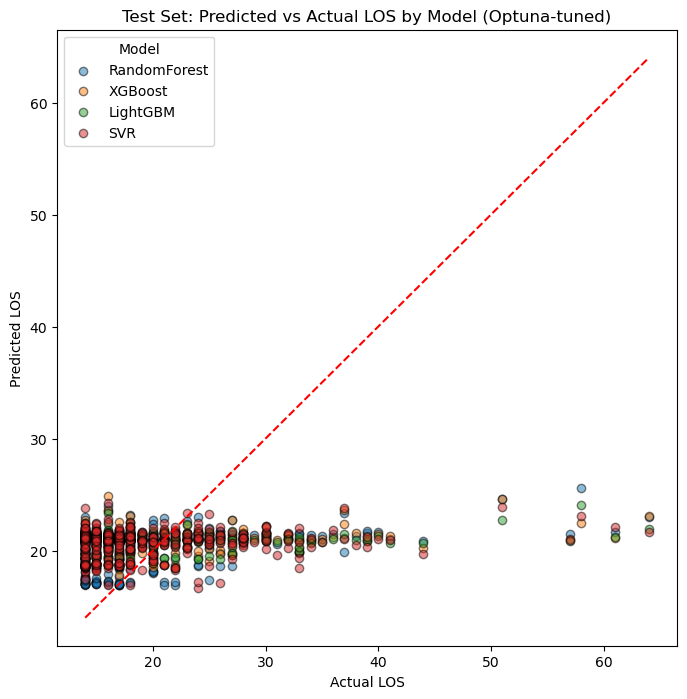

In [152]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, rf_pred, alpha=0.5, edgecolor='k', label='RandomForest')
ax.scatter(y_test, xgb_pred, alpha=0.5, edgecolor='k', label='XGBoost')
ax.scatter(y_test, lgb_pred, alpha=0.5, edgecolor='k', label='LightGBM')
ax.scatter(y_test, svr_pred, alpha=0.5, edgecolor='k', label='SVR')

min_val = min(y_test.min(), rf_pred.min(), xgb_pred.min(), lgb_pred.min(), svr_pred.min())
max_val = max(y_test.max(), rf_pred.max(), xgb_pred.max(), lgb_pred.max(), svr_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--')

ax.set_xlabel('Actual LOS')
ax.set_ylabel('Predicted LOS')
ax.set_title('Test Set: Predicted vs Actual LOS by Model (Optuna-tuned)')
ax.legend(title='Model')

plt.savefig(f"{output_path}/predicted_vs_actual_test.png", dpi=150, bbox_inches='tight')
plt.show()